# 05 - Avaliação final no teste e interpretação

**Objetivo:** medir os dois modelos no conjunto de **teste** — que não foi tocado em nenhuma etapa anterior — escolher um modelo final e entender, com Grad-CAM, em que regiões da imagem ele se baseia para decidir.

Esta é a etapa mais importante do projeto: é aqui que descobrimos se o que vimos na validação realmente se confirma.

## 1. Preparação

In [1]:
import sys
sys.path.append("..")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report,
                              f1_score, precision_score, recall_score)

from src import dados, gradcam, modelos, treino

torch.manual_seed(42)

PASTA_FIGURAS = Path("..") / "reports" / "figures"
PASTA_MODELOS = Path("..") / "models"

dispositivo = treino.escolher_dispositivo()
loaders, tabelas = dados.criar_dataloaders(tamanho_lote=32)
pesos_classe = dados.pesos_de_classe(tabelas["treino"])
criterio = torch.nn.CrossEntropyLoss(weight=pesos_classe.to(dispositivo))

print(f"Conjunto de teste: {len(tabelas['teste'])} imagens (nunca usado até agora)")

Conjunto de teste: 624 imagens (nunca usado até agora)


## 2. Carregando os dois modelos treinados

Cada um foi salvo com os pesos da sua melhor época na validação (notebooks 03 e 04).

In [2]:
cnn_simples = modelos.CNNSimples().to(dispositivo)
cnn_simples.load_state_dict(torch.load(PASTA_MODELOS / "cnn_simples.pt", map_location=dispositivo))

resnet18 = modelos.resnet18_transferencia().to(dispositivo)
resnet18.load_state_dict(torch.load(PASTA_MODELOS / "resnet18.pt", map_location=dispositivo))

print("Modelos carregados.")

Modelos carregados.


## 3. Desempenho no teste

In [3]:
_, rotulos_cnn, previsoes_cnn = treino.avaliar(cnn_simples, loaders["teste"], criterio, dispositivo)
_, rotulos_res, previsoes_res = treino.avaliar(resnet18, loaders["teste"], criterio, dispositivo)

print("=== CNN simples — TESTE ===")
print(classification_report(rotulos_cnn, previsoes_cnn, target_names=dados.CLASSES, digits=3))
print("=== ResNet18 (transfer learning) — TESTE ===")
print(classification_report(rotulos_res, previsoes_res, target_names=dados.CLASSES, digits=3))

=== CNN simples — TESTE ===
              precision    recall  f1-score   support

      NORMAL      0.974     0.487     0.650       234
   PNEUMONIA      0.763     0.992     0.863       390

    accuracy                          0.803       624
   macro avg      0.869     0.740     0.756       624
weighted avg      0.842     0.803     0.783       624

=== ResNet18 (transfer learning) — TESTE ===
              precision    recall  f1-score   support

      NORMAL      0.914     0.816     0.862       234
   PNEUMONIA      0.896     0.954     0.924       390

    accuracy                          0.902       624
   macro avg      0.905     0.885     0.893       624
weighted avg      0.903     0.902     0.901       624



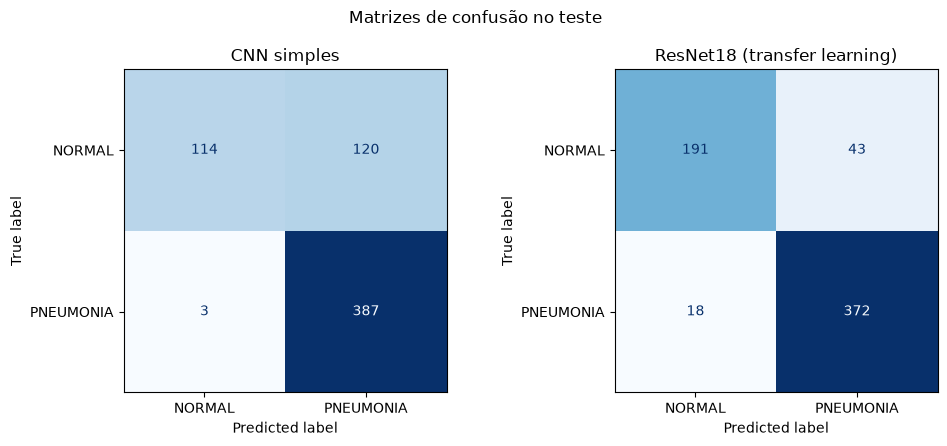

In [4]:
fig, eixos = plt.subplots(1, 2, figsize=(10, 4.5))
ConfusionMatrixDisplay.from_predictions(rotulos_cnn, previsoes_cnn, display_labels=dados.CLASSES,
                                         cmap="Blues", ax=eixos[0], colorbar=False)
eixos[0].set_title("CNN simples")
ConfusionMatrixDisplay.from_predictions(rotulos_res, previsoes_res, display_labels=dados.CLASSES,
                                         cmap="Blues", ax=eixos[1], colorbar=False)
eixos[1].set_title("ResNet18 (transfer learning)")
fig.suptitle("Matrizes de confusão no teste")
plt.tight_layout()
fig.savefig(PASTA_FIGURAS / "05_confusao_teste.png", dpi=120)
plt.show()

## 4. Validação x teste: o que mudou?

Colocamos lado a lado o que cada modelo mostrou na validação (notebook 04) e o que mostrou agora no teste, que é o dado nunca visto de verdade.

In [5]:
def metricas(rotulos, previsoes):
    return {
        "accuracy": accuracy_score(rotulos, previsoes),
        "recall_pneumonia": recall_score(rotulos, previsoes, pos_label=1),
        "recall_normal": recall_score(rotulos, previsoes, pos_label=0),
        "precisao_pneumonia": precision_score(rotulos, previsoes, pos_label=1),
        "f1_pneumonia": f1_score(rotulos, previsoes, pos_label=1),
    }

# Números da validação, copiados dos notebooks 03 e 04 (para comparar lado a lado)
val_cnn = {"accuracy": 0.963, "recall_pneumonia": 0.982, "recall_normal": 0.907,
           "precisao_pneumonia": 0.968, "f1_pneumonia": 0.975}
val_res = {"accuracy": 0.948, "recall_pneumonia": 0.938, "recall_normal": 0.978,
           "precisao_pneumonia": 0.992, "f1_pneumonia": 0.964}

comparacao = pd.DataFrame({
    "CNN simples (validação)": val_cnn,
    "CNN simples (teste)": metricas(rotulos_cnn, previsoes_cnn),
    "ResNet18 (validação)": val_res,
    "ResNet18 (teste)": metricas(rotulos_res, previsoes_res),
}).T.round(3)
comparacao

,accuracy,recall_pneumonia,recall_normal,precisao_pneumonia,f1_pneumonia
CNN simples (validação),0.963,0.982,0.907,0.968,0.975
CNN simples (teste),0.803,0.992,0.487,0.763,0.863
ResNet18 (validação),0.948,0.938,0.978,0.992,0.964
ResNet18 (teste),0.902,0.954,0.816,0.896,0.924


**O que os números mostram:**

- Na validação, a CNN simples parecia melhor (encontrava 98,2% dos casos de pneumonia). **No teste, essa vantagem some.** O recall de NORMAL da CNN simples despenca de 90,7% (validação) para **48,7%** (teste): ela passa a classificar quase tudo como PNEUMONIA. Na prática, ela achou um "truque" que funcionava bem só dentro da validação, e não fora dela — sinal de que ela não aprendeu o problema de verdade, mesmo sem parecer estar decorando o treino nas curvas do notebook 03.
- A ResNet18 caiu bem menos entre validação e teste (acerto geral de 94,8% para 90,2%; recall de pneumonia de 93,8% para 95,4% — até melhorou um pouco). Ela se manteve muito mais estável.
- **Por que isso acontece?** As fotos do `test` original do Kaggle parecem ter características um pouco diferentes das fotos de `train`/`val`, mesmo sendo o mesmo dataset — isso já é conhecido sobre esse conjunto de dados específico. A CNN simples, treinada do zero só com as nossas ~4 mil imagens, é mais sensível a essa diferença. A ResNet18 já vem com um "olho treinado" para reconhecer padrões (bordas, texturas, formas), aprendido antes com 1,2 milhão de imagens bem variadas, o que a deixa mais preparada para lidar com fotos um pouco diferentes das que ela viu no treino.
- **Lição principal:** ir bem na validação não garante ir bem na vida real. Por isso o teste existe, e por isso só olhamos para ele no final, depois de todas as decisões já tomadas.

## 5. Modelo final escolhido: ResNet18

Definimos recall de pneumonia como métrica principal, e olhando só esse número a CNN simples ainda vence por pouco (99,2% x 95,4%). Mas isso é enganoso aqui: a CNN simples alcança esse recall alto porque **classifica quase tudo como PNEUMONIA** (por isso o recall de NORMAL caiu para 48,7%). Um modelo assim teria pouca utilidade real: metade dos pacientes normais seria sinalizada como suspeita, sobrecarregando a revisão médica e reduzindo a confiança no sistema.

A **ResNet18** tem recall de pneumonia quase igual (95,4%) com uma taxa de falsos positivos bem menor (recall de NORMAL de 81,6%) e melhor accuracy geral (90,2%). É o modelo mais equilibrado e mais confiável dos dois, e o que escolhemos para seguir.

## 6. Grad-CAM: onde o modelo está "olhando"?

O Grad-CAM (implementado em [`src/gradcam.py`](../src/gradcam.py)) gera um mapa de calor: vermelho/amarelo indica as regiões que mais pesaram a favor da classe prevista; azul indica pouca influência.

Vamos ver 3 casos:
1. Um verdadeiro positivo (pneumonia corretamente identificada).
2. Um verdadeiro negativo (normal corretamente identificado).
3. Um caso que o modelo errou.

Isso ajuda a checar algo importante: o modelo está mesmo olhando para os pulmões, ou está usando algum atalho (como uma marca no canto da imagem)?

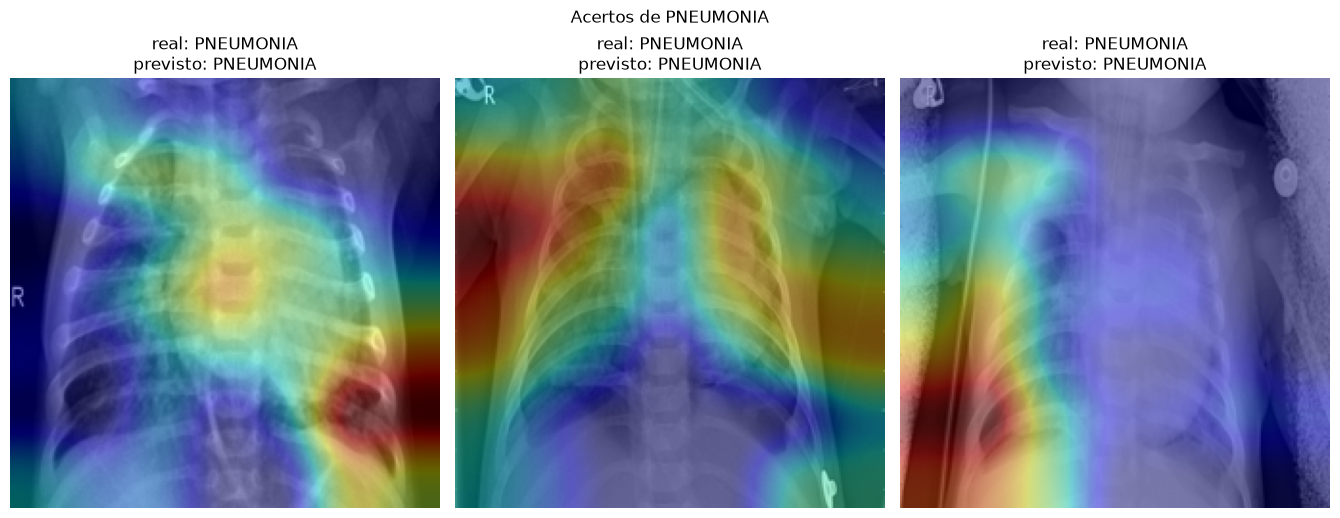

In [6]:
def mostrar_gradcam(indices, titulo, arquivo_saida):
    cam = gradcam.GradCAM(resnet18, resnet18.layer4)
    tf_avaliacao = dados.transformacoes_avaliacao()

    fig, eixos = plt.subplots(1, len(indices), figsize=(4.5 * len(indices), 5))
    if len(indices) == 1:
        eixos = [eixos]

    for eixo, posicao in zip(eixos, indices):
        linha = tabelas["teste"].iloc[posicao]
        imagem_original = Image.open(linha["caminho"]).convert("L").resize((224, 224))
        imagem_tensor = tf_avaliacao(Image.open(linha["caminho"]))

        classe_prevista = previsoes_res[posicao]
        mapa = cam.gerar_mapa(imagem_tensor, classe_prevista, dispositivo)
        mapa = gradcam.redimensionar_mapa(mapa, (224, 224))

        eixo.imshow(imagem_original, cmap="gray")
        eixo.imshow(mapa, cmap="jet", alpha=0.4)
        eixo.set_title(f"real: {dados.CLASSES[linha['rotulo']]}\nprevisto: {dados.CLASSES[classe_prevista]}")
        eixo.axis("off")

    fig.suptitle(titulo, y=1.03)
    plt.tight_layout()
    fig.savefig(PASTA_FIGURAS / arquivo_saida, dpi=120)
    plt.show()


previsoes_res_array = np.array(previsoes_res)
rotulos_res_array = np.array(rotulos_res)

acertos_pneumonia = np.where((previsoes_res_array == 1) & (rotulos_res_array == 1))[0]
acertos_normal = np.where((previsoes_res_array == 0) & (rotulos_res_array == 0))[0]
erros = np.where(previsoes_res_array != rotulos_res_array)[0]

mostrar_gradcam(acertos_pneumonia[:3], "Acertos de PNEUMONIA", "05_gradcam_acertos_pneumonia.png")

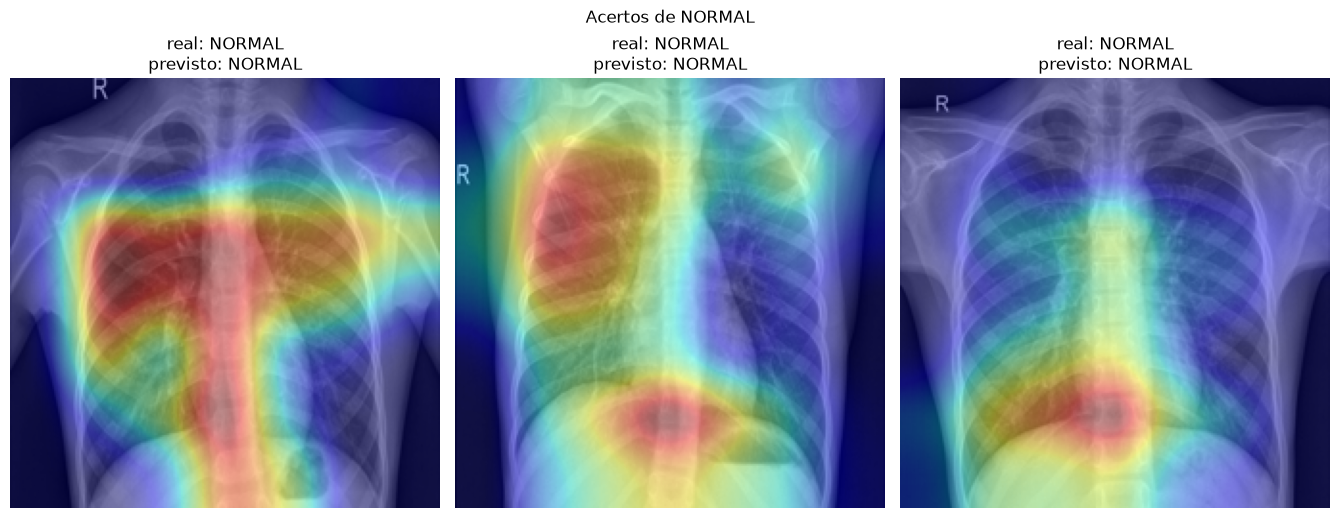

In [7]:
mostrar_gradcam(acertos_normal[:3], "Acertos de NORMAL", "05_gradcam_acertos_normal.png")

Total de erros no teste: 61 de 624


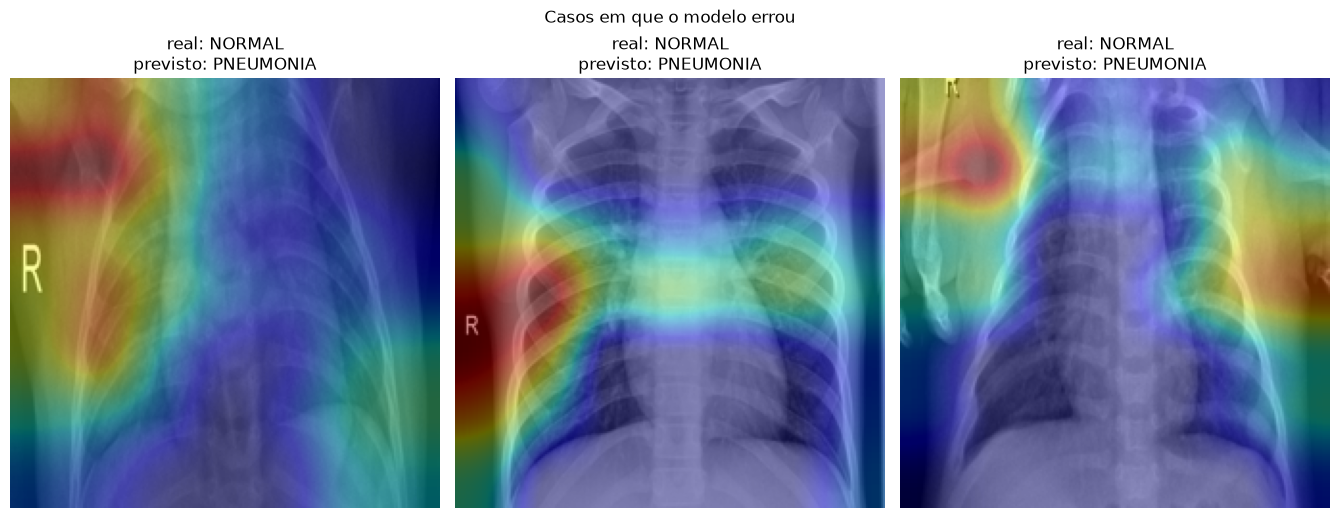

In [8]:
print(f"Total de erros no teste: {len(erros)} de {len(tabelas['teste'])}")
mostrar_gradcam(erros[:3], "Casos em que o modelo errou", "05_gradcam_erros.png")

Nos acertos, o mapa de calor se concentra sobre os pulmoes e a regiao do coracao - o que e tranquilizador, e a regiao clinicamente relevante. **Mas em casos de erro, o mapa de calor as vezes se concentra sobre a letra "R"** (marcador de lateralidade, colocado pelo tecnico de radiologia no canto da imagem) em vez do tecido pulmonar. Isso e um indicio real de que, nesses casos, o modelo pode estar usando um atalho (a presenca, o tamanho ou a posicao dessa marcacao) em vez de analisar a anatomia - exatamente o tipo de problema que o Grad-CAM serve para descobrir.

## 7. Discussão crítica

**O modelo pode ser usado na prática? Como?**

Com cautela, e só como **apoio à triagem** — nunca como diagnóstico:

- Pode ajudar a **priorizar a fila de leitura** de radiografias: casos com alta chance de pneumonia sobem para revisão mais cedo, o que ajuda num hospital com muitos exames e poucos radiologistas disponíveis na hora.
- Pode funcionar como uma **segunda opinião automática**: se o modelo discorda muito do laudo inicial, o exame pode ser marcado para uma segunda checagem.
- **Não deve decidir sozinho** se um paciente tem ou não pneumonia. O recall de pneumonia (95,4%) quer dizer que, a cada 100 pacientes com pneumonia, cerca de 5 passariam despercebidos pelo modelo — inaceitável como decisão final, mas aceitável como uma camada extra de triagem, desde que o médico sempre revise o caso.

**Limitações a ter em mente:**

- O dataset vem de um único grupo de hospitais e é majoritariamente de crianças pequenas (1 a 5 anos). O modelo pode não funcionar tão bem em radiografias de adultos ou tiradas com outros aparelhos.
- Vimos uma diferença real entre as fotos de `train`/`val` e as de `test` dentro do próprio dataset. Isso reforça que, antes de qualquer uso real, o modelo precisaria ser testado com dados de outras fontes (outros hospitais, outros aparelhos, outras idades).
- O Grad-CAM ajuda a checar que o modelo olha para os pulmões (e não para um atalho, como uma marca no canto da imagem), mas não garante que o raciocínio dele seja clinicamente correto — ele mostra "onde" o modelo olhou, não necessariamente "por quê" no sentido médico.

**Resumindo:** o modelo é um exercício acadêmico sólido, com um processo honesto de validação e teste. Como ferramenta real de triagem, ele ainda precisaria de mais dados, validação clínica, e principalmente de um médico sempre com a palavra final.